# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

Цель эксперимента:

Проверить гипотезу о том, что новый алгоритм рекомендаций контента увеличивает пользовательское вовлечение в приложение

Вторичные метрики для мониторинга:

Среднее количество просмотренных страниц за сессию

Тип теста: Двусторонний с уровнем значимости α=0.05

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [2]:
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.



In [3]:
unique_ses_per_user = sessions_history.groupby('user_id')['session_id'].nunique()
unique_ses_per_user.max()

10

In [4]:
max_sessions_user = unique_ses_per_user.idxmax()
user_max_sessions = sessions_history[sessions_history['user_id'] == max_sessions_user]
user_max_sessions.head(1)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования.

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

In [5]:
daily_total_users = sessions_history.groupby('session_date')['user_id'].nunique().reset_index()
daily_total_users.columns = ['session_date', 'total_users']

In [6]:
daily_registered = sessions_history[sessions_history['registration_flag'] == 1].groupby('session_date')['user_id'].nunique().reset_index()
daily_registered.columns = ['session_date', 'registered_users']

In [7]:
daily_stats = pd.merge(daily_total_users, daily_registered, on='session_date')
daily_stats = daily_stats.sort_values('session_date')
daily_stats['registered_share'] = daily_stats['registered_users'] / daily_stats['total_users']

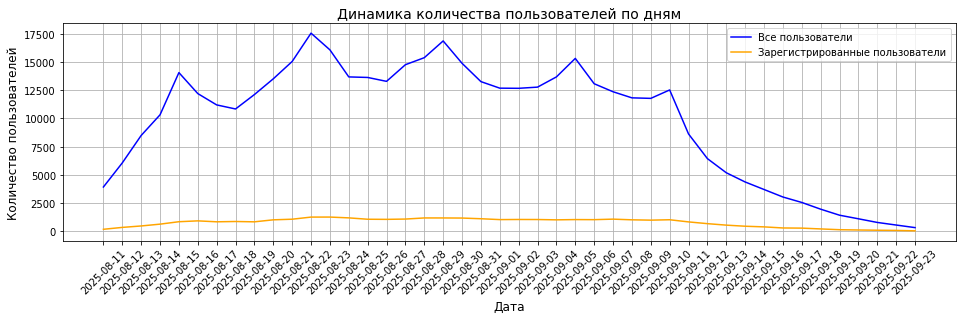

In [8]:
plt.figure(figsize=(16, 4))
# 1/ Общее количество пользователей и зарегистрированных пользователей
plt.plot(daily_stats['session_date'], daily_stats['total_users'], 
         label='Все пользователи', color='blue')
plt.plot(daily_stats['session_date'], daily_stats['registered_users'], 
         label='Зарегистрированные пользователи', color='orange')
plt.title('Динамика количества пользователей по дням', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.grid()
plt.legend()
plt.xticks(rotation=45);

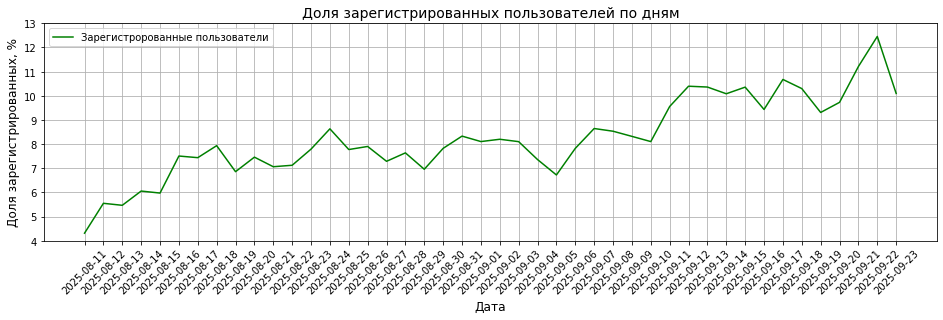

In [9]:
plt.figure(figsize=(16, 4))
# 2/Доля зарегистрированных пользователей от общего числа 
plt.plot(daily_stats['session_date'], daily_stats['registered_share'] * 100, 
         label='Зарегистророванные пользователи', color='green')
plt.title('Доля зарегистрированных пользователей по дням', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Доля зарегистрированных, %', fontsize=12)
plt.ylim(4, 13)
plt.grid()
plt.legend()
plt.xticks(rotation=45);

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

- Найдите количество сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

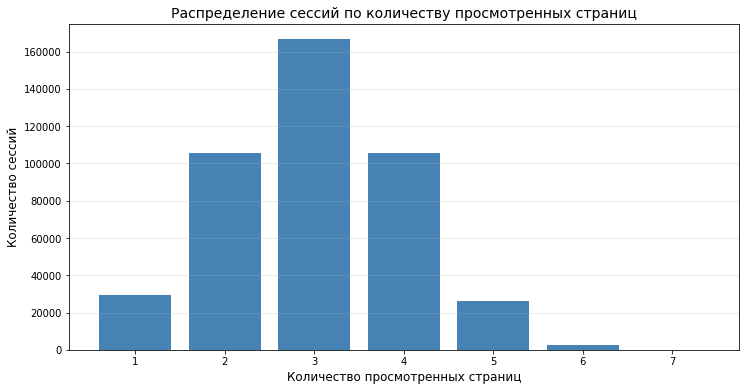

In [10]:
# группировка по кол-ву сессий и подсчет
page_sessions = sessions_history.groupby('page_counter').size().reset_index(name='session_count')
page_sessions = page_sessions.sort_values('page_counter')

plt.figure(figsize=(12, 6))
plt.bar(page_sessions['page_counter'], page_sessions['session_count'], 
        color='steelblue')
plt.title('Распределение сессий по количеству просмотренных страниц', fontsize=14)
plt.xlabel('Количество просмотренных страниц', fontsize=12)
plt.ylabel('Количество сессий', fontsize=12)
plt.grid(axis='y', alpha=0.3)

На графике явно выделяется наиболее популярное количесвто просмотренных сессий - 3(по три страницы смотрели более 160000 раз). Примерно 105000 раз просматривали по 3 или 4 страницы за сессию. Реже всего задействуются по 7 и 6 страниц за одну сессию.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех сессий по дням за весь период наблюдения.

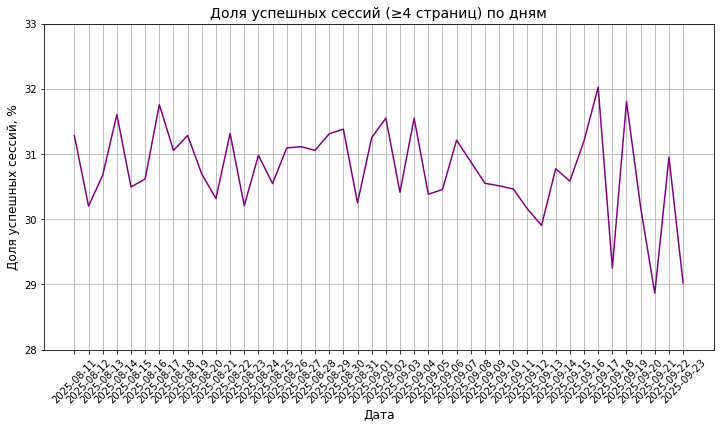

In [11]:
sessions_history['good_session'] = (sessions_history['page_counter'] >=4).astype(int)
daily_good_sessions = sessions_history.groupby('session_date').agg(total_sessions=('session_id', 'count'),
    good_sessions=('good_session', 'sum')).reset_index()
plt.figure(figsize=(12, 6))
plt.plot(daily_good_sessions['session_date'], daily_good_sessions['good_sessions']/daily_good_sessions['total_sessions'] * 100, 
         color='purple')
plt.title('Доля успешных сессий (≥4 страниц) по дням', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Доля успешных сессий, %', fontsize=12)
plt.grid()
plt.ylim(28, 33)
plt.xticks(rotation=45);

Доля успешных сессий в рассматриваемый период с 11.08.2025 по 23.09.2025 колеблется в интервале от 28,9% до 32%, что говорит об умереной стабильности. Отсутствуют резкие скачки или падения, что говорит о предсказуемом пользовательском поведении

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Сформулировать нулевую и альтернативную гипотезы

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1 Формулировка нулевой и альтернативной гипотез

Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

О какой метрике идёт речь? Доля успешных сессий (daily_good_sessions['good_sessions']/daily_good_sessions['total_sessions'] * 100) 
Как она будет учтена в формулировке гипотез?
количественное определение успеха в сравнении с нулевой гипотезой


Сформулируйте нулевую и альтернативную гипотезы:






H0: новый алгоритм не повлияет на долю успешных сессий 
    (пользователи просматривают столько же страниц, сколько и при старом алгоритме).
    
    H0: p(старая) = p(новая)
    
H1: новый алгоритм повлияет на долю успешных сессий 
    (пользователи просматривают больше страниц, чем при старом алгоритме).
    
    H1: p(старая) < p(новая)

#### 2.2. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [12]:

base_good_session_ratio = sessions_history['good_session'].mean()

# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p =  0.3 # Базовый уровень доли
mde = 0.03 * p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


In [13]:
print(f"Базовый уровень доли успешных сессий: {base_good_session_ratio*100:.1f}%")
print(f"Необходимый размер выборки для каждой группы: {int(sample_size):,} пользователей")
print(f"Общий размер выборки для теста: {int(sample_size)*2:,} пользователей")

Базовый уровень доли успешных сессий: 30.9%
Необходимый размер выборки для каждой группы: 41,040 пользователей
Общий размер выборки для теста: 82,080 пользователей


#### 2.3. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [14]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean().astype(int)

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(int(sample_size)*2 / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [15]:
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

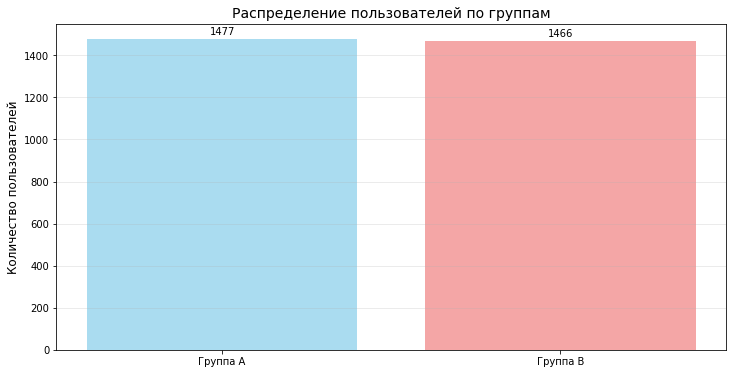

In [16]:
users_per_group = sessions_test_part.groupby('test_group')['user_id'].nunique()
users_per_group 
A_part = users_per_group.get("A", 0)
B_part = users_per_group.get("B", 0)

if A_part > 0:
    percentage_diff = 100 * abs(A_part - B_part) / A_part
    
plt.figure(figsize=(12, 6))
groups = ['Группа A', 'Группа B']
users_counts = [A_part, B_part]

bars = plt.bar(groups, users_counts, color=['skyblue', 'lightcoral'], alpha=0.7)
plt.title('Распределение пользователей по группам', fontsize=14)
plt.ylabel('Количество пользователей', fontsize=12)
plt.grid(axis='y', alpha=0.3)

for bar, count in zip(bars, users_counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + max(users_counts)*0.01,
             f'{count:}', ha='center', va='bottom')

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [17]:
users_in_A = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].unique())
users_in_B = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].unique())
intersection = users_in_A.intersection(users_in_B)
len(intersection)

0

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


In [18]:
device_users_A = (sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('device')['user_id'].nunique())
device_users_B = (sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('device')['user_id'].nunique())

total_A = device_users_A.sum()
total_B = device_users_B.sum()

device_percent_A = (device_users_A / total_A) * 100
device_percent_B = (device_users_B / total_B) * 100

device_comparison = pd.DataFrame({
    'Группа A_%': device_percent_A,
    'Группа B_%': device_percent_B,
    'Группа A': device_users_A,
    'Группа B': device_users_B
}).fillna(0).sort_index()


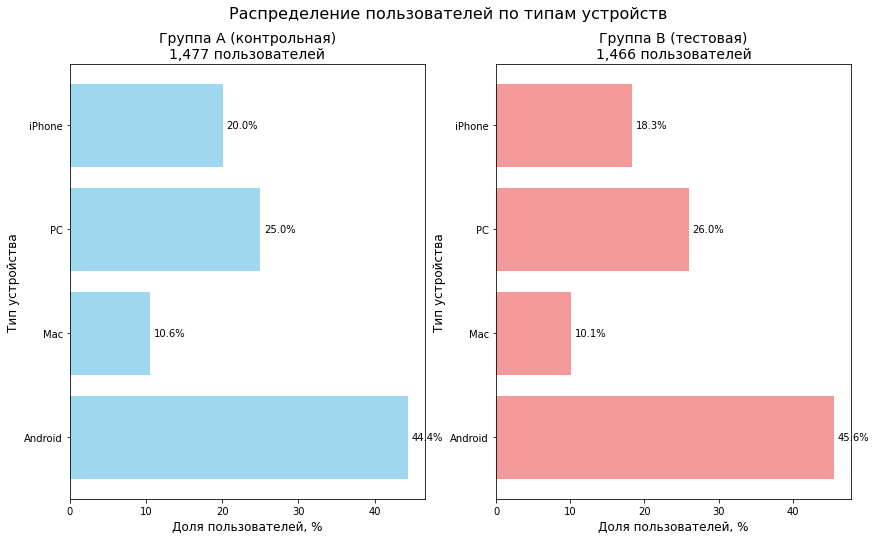

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))
all_devices = sorted(set(device_percent_A.index) | set(device_percent_B.index))

# 1. Группа A
y_pos = range(len(all_devices))
values_A = [device_percent_A.get(device, 0) for device in all_devices]
bars1 = ax1.barh(y_pos, values_A, color='skyblue', alpha=0.8)
ax1.set_xlabel('Доля пользователей, %', fontsize=12)
ax1.set_ylabel('Тип устройства', fontsize=12)
ax1.set_title(f'Группа A (контрольная)\n{total_A:,} пользователей', fontsize=14)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(all_devices)

for bar, value in zip(bars1, values_A):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{value:.1f}%', va='center', fontsize=10)

# 2. Группа B
values_B = [device_percent_B.get(device, 0) for device in all_devices]
bars2 = ax2.barh(y_pos, values_B, color='lightcoral', alpha=0.8)
ax2.set_xlabel('Доля пользователей, %', fontsize=12)
ax2.set_ylabel('Тип устройства', fontsize=12)
ax2.set_title(f'Группа B (тестовая)\n{total_B:,} пользователей', fontsize=14)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(all_devices)

for bar, value in zip(bars2, values_B):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{value:.1f}%', va='center', fontsize=10)

plt.suptitle('Распределение пользователей по типам устройств', fontsize=16);

Опираясь на график можно сделать вывод, что расхождения между группами составляют несколько процентов. наибольшее расхождение в сторону увеличения пользователей группы Б наблюдается в Mac устройствах, а наименьшее с PC с уменьшением пользователей пруппы Б на 0.8%

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.


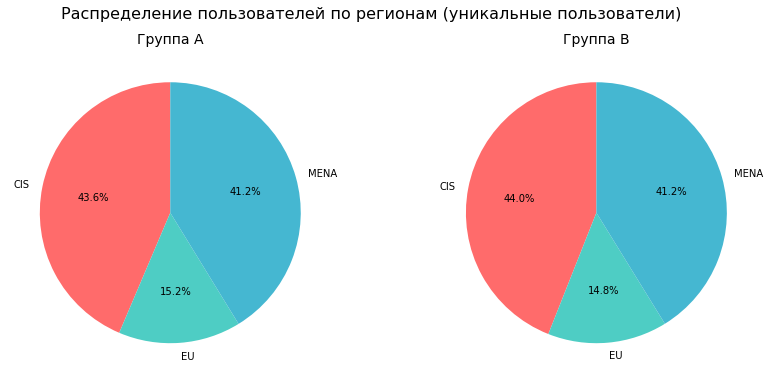

In [20]:
regions_A_counts = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('region')['user_id'].nunique()
regions_B_counts = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('region')['user_id'].nunique()

regions_A = (regions_A_counts / regions_A_counts.sum()) * 100
regions_B = (regions_B_counts / regions_B_counts.sum()) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
region_colors = {'CIS': '#FF6B6B', 'EU': '#4ECDC4', 'MENA': '#45B7D1'}

all_regions = sorted(set(regions_A.index) | set(regions_B.index))
colors = [region_colors.get(region, '#CCCCCC') for region in all_regions]

# собираем значения в правильном порядке
values_A = [regions_A.get(region, 0) for region in all_regions]
values_B = [regions_B.get(region, 0) for region in all_regions]

ax1.pie(values_A, labels=all_regions, autopct='%1.1f%%', startangle=90, colors=colors)
ax1.set_title('Группа A', fontsize=14)

ax2.pie(values_B, labels=all_regions, autopct='%1.1f%%', startangle=90, colors=colors)
ax2.set_title('Группа B', fontsize=14)

plt.suptitle('Распределение пользователей по регионам (уникальные пользователи)', fontsize=16);

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

Распределение количества пользователей между группами

Группа A (контрольная): 1477 пользователей

Группа B (тестовая): 1466 пользователей

Пересечение групп отсутствует, выборки независимы

Распределение пользователей по типам устройств можно считать равномерным. Все различия находятся в пределах допустимой погрешности (менее 3%)

Наибольшее расхождение: IPhone устройства (разница 1.7%)

Наименьшее расхождение: Mac устройства (разница 0.4%)

MENA: +0% в группе B - неизменно

CIS: +0,4% в группе B - увеличение

A/B-тест проходит без значительных отклонений в распределении по регионам

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [21]:
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')
sessions_test['good_session'] = (sessions_test['page_counter'] >=4).astype(int)
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2. Проверка корректности результатов теста

Прежде чем приступать к анализу ключевых продуктовых метрик, необходимо убедиться, что тест проведён корректно и вы будете сравнивать две сопоставимые группы.

- Рассчитайте количество уникальных сессий для каждого дня и обеих тестовых групп, используя группировку.

- Проверьте, что количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимыми. Используйте статистический тест, который позволит сделать вывод о равенстве средних двух выборок.

- В качестве ответа выведите на экран полученное значение p-value и интерпретируйте его.

H₀ (нулевая гипотеза) — количество уникальных дневных сессий не различается между тестовой и контрольной группами.

H₁ (альтернативная гипотеза) — количество уникальных дневных сессий в тестовой группе меньше, чем в контрольной группе.

In [22]:
unique_sessions_per_day_per_group = sessions_test.groupby(['session_date', 'test_group'])['session_id'].nunique()
sessions_data = unique_sessions_per_day_per_group.unstack()
group_A = sessions_data['A'].values
group_B = sessions_data['B'].values

t_stat, p_value = stats.ttest_ind(group_A, group_B, equal_var=True)
if p_value > 0.05:
    print(f"p-value = {p_value:.4f} > 0.05")
    print("Статистически значимых различий в количестве дневных сессий между группами A и B нет.")
else:
    print(f"p-value = {p_value:.4f} < 0.05")
    print("Статистически значимые различия в количестве дневных сессий между группами A и B есть.")

p-value = 0.9382 > 0.05
Статистически значимых различий в количестве дневных сессий между группами A и B нет.


Нет оснований отвергать нулевую гипотезу (H₀)

#### 4.3. Сравнение доли успешных сессий

Когда вы убедились, что количество сессий в обеих выборках не различалось, можно переходить к анализу ключевой метрики — доли успешных сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [23]:
good_A = sessions_test[sessions_test['test_group'] == 'A']['good_session'].mean()
good_B = sessions_test[sessions_test['test_group'] == 'B']['good_session'].mean()

In [24]:
good_A_percent = good_A * 100 
good_B_percent = good_B * 100  
diff_pp = good_B_percent - good_A_percent
print(f"Группа A: {good_A_percent:.2f}% успешных сессий, Группа B: {good_B_percent:.2f}% успешных сессий")
print(f"В процентных пунктах: {diff_pp:.2f} п.п.")

Группа A: 30.77% успешных сессий, Группа B: 31.83% успешных сессий
В процентных пунктах: 1.06 п.п.


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [25]:
success_A = sessions_test[sessions_test['test_group'] == 'A']['good_session'].sum()
total_A = sessions_test[sessions_test['test_group'] == 'A'].shape[0]
success_B = sessions_test[sessions_test['test_group'] == 'B']['good_session'].sum()
total_B = sessions_test[sessions_test['test_group'] == 'B'].shape[0]
count = np.array([success_A, success_B])  #успехи общие
isp = np.array([total_A, total_B])      #всего испытаний
z_stat, p_value = proportions_ztest(count, isp, alternative='smaller')
if p_value > 0.05:
    print(f"p-value: {p_value:.6f}, статистически значимых изменений не обнаружено. Нет оснований отвергать нулевую гипотезу H₀")
else:
    print(f"p-value: {p_value:.6f}, статистически значимые изменения обнаружены. Отвергаем нулевую гипотезу H₀")

p-value: 0.000157, статистически значимые изменения обнаружены. Отвергаем нулевую гипотезу H₀


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

Период теста: с 2025-10-14 по 2025-11-02 (20 дней)

Цель теста: Проверить эффективность нового алгоритма рекомендаций контента

Ключевая метрика: Доля успешных сессий (≥4 просмотренных страниц)

Тип теста: Односторонний (проверка улучшения)

Уровень значимости: α = 0.05

Группа A (контрольная): 1477 пользователей

Группа B (тестовая): 1466 пользователей

Распределение трафика: равномерное (p-value = 0.9382 > 0.05)

Независимость групп: пересечений пользователей нет

Баланс по устройствам: равномерный (максимальная разница 1.7%)

Баланс по регионам: равномерный (максимум на 0.4%)

Значение p.value = 0.000157

Новый алгоритм рекомендаций статистически значимо увеличивает долю успешных сессий. Новый алгоритм рекомендаций работает. Изменения низковероятно могут оказаться случайными. Рекомендуется к внедрению.